# Дилатация

## Подготовим изображение

### Откроем и бинаризуем каринку

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
img = cv2.imread('picture.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Конвертируем BGR -> RGB для корректного отображения

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

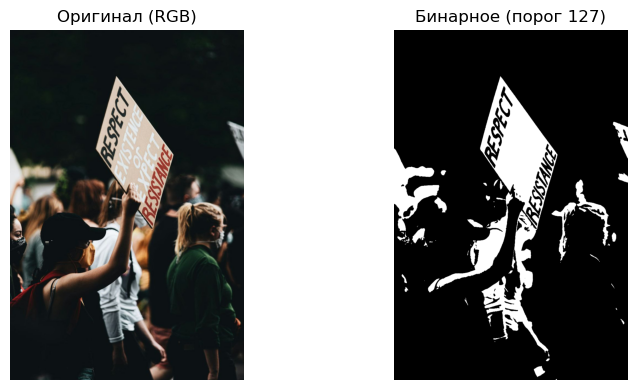

Бинарный массив:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Оригинал (RGB)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary, cmap='gray')
plt.title('Бинарное (порог 127)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Бинарный массив:")
print(binary)

In [5]:
h, w = binary.shape
print("Размер изображение "+str(h)+"x"+str(w))

Размер изображение 1280x853


## Ручная реализация

### Если есть один белый пиксель

In [6]:
def manual_dilation(image):
    h, w = image.shape
    result = np.zeros_like(image)
    
    for i in range(h):
        for j in range(w):
            window = image[max(0, i-1):min(h-1, i+1)+1, max(0, j-1):min(w-1, j+1)+1]
            result[i, j] = np.max(window)
    
    return result

### Выполняем ручную дилаттацию и считаем время

In [13]:
start_time = time.time()
manual_result = manual_dilation(binary)
manual_time = time.time() - start_time

## Библиотечная реализация

In [14]:
kernel = np.ones((3,3), np.uint8)
start_time = time.time()
opencv_result = cv2.dilate(binary, kernel, iterations=1)
opencv_time = time.time() - start_time

## Сравним дилатацию

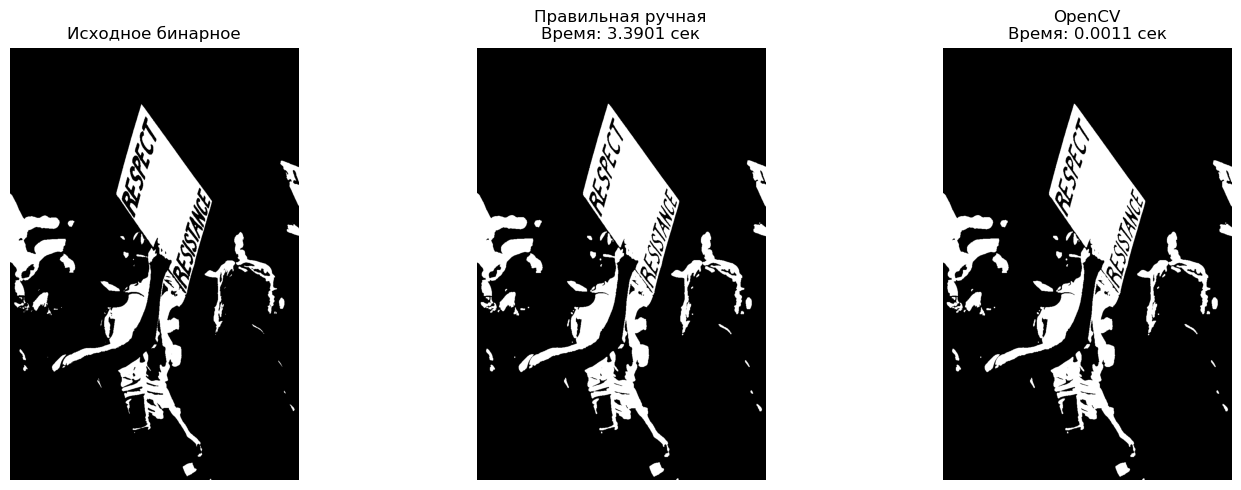

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap='gray')
plt.title('Исходное бинарное')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(manual_result, cmap='gray')
plt.title(f'Правильная ручная\nВремя: {manual_time:.4f} сек')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(opencv_result, cmap='gray')
plt.title(f'OpenCV\nВремя: {opencv_time:.4f} сек')
plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
difference = np.sum(manual_result != opencv_result)
if difference == 0:
    print("Результат полностью совпадает")
else:
    print(f"✗ Есть различия: {difference} пикселей")

Результат полностью совпадает


In [17]:
print(f"Ручная: {manual_time:.6f} сек")
print(f"OpenCV: {opencv_time:.6f} сек")

Ручная: 3.390085 сек
OpenCV: 0.001062 сек


In [18]:
print(f"OpenCV быстрее в {manual_time/opencv_time:.1f} раз")

OpenCV быстрее в 3191.7 раз
